---
title: "Football Momentum Analysis"
format:
  html:
    code-fold: true
    code-summary: "View Code"
    theme: cosmo
---

**Do hydration breaks in football actually affect match momentum?** Well, depending on who you ask, the answer is either a definite yes, a hard no, or somewhere in between.

Hydration breaks are a relatively new concept in football. They were officially trialed during the Club World Cup in the summer of 2025 as a kind of dry run for the 2026 World Cup. Ever since, they’ve been a major point of contention. For fans watching at home, it’s mostly just frustrating - an unwanted commercial break right when the game starts to get good.

But it’s not just the fans complaining. Throughout the group stage, several players and coaching staff have spoken out against these breaks, arguing that they completely kill their rhythm and momentum.

Interestingly, these complaints often come from the "underdog" camps. For instance, after Jordan’s match against Austria - a game that was tied 1-1 with Jordan looking dangerous - the team’s staff felt the hydration break in the second half knocked them off balance. Shortly after play resumed, they conceded twice and ended up losing the match.

Even the German national team coach weighed in after their game against Curaçao. Curaçao had been the surprise of the tournament, holding Germany to a 1-1 draw and looking really sharp. But right after the first hydration break, they suddenly conceded two goals before halftime and eventually lost 7-1. Would the result have been different for little Curaçao if not for that break? It’s impossible to say for sure. Football is chaotic, unpredictable, and influenced by a million different things every second.

After several group stage matches, an assumption emerged that these drinks breaks could trigger a momentum shift. Others believed that the breaks actually kill momentum and slow the game down. In football, as usual, there is no single truth, and it all depends on the fan's perspective. I thought it would be interesting to see what the data actually says.

<img src="https://cassette.sphdigital.com.sg/image/straitstimes/b6d0bccb706ec1d9a92e927a59cb50d4e3ae831a9fb1d934c00712ababbfbcbb" width="600">

**So, how do you actually measure something as elusive as "momentum"?**

Football is going through a massive wave of "Americanization" right now. The world’s most popular game is becoming deeply data-driven, and we’re seeing advanced analytics applied to every single touch of the ball. To track momentum, I needed a way to quantify it minute-by-minute.

Luckily, I could tap into [Sofascore’s](https://www.sofascore.com/) "Live Attack Momentum" data. In a nutshell, their algorithm calculates a live score for each team by weighing high-intensity events like dangerous attacks, shots on target, and shots off target, while also considering ball possession in dangerous areas. It essentially translates the "vibe" of the game into a concrete numerical value for every single minute.

I managed to scrape this momentum data for every match of the World Cup leading up to the semifinals. On top of that, I pulled official match event logs - recording exactly when hydration breaks happened, when shots were taken, and even pre-match betting odds to categorize teams as either "favorites" or "underdogs." the code i used can be reviewed [here](https://github.com/maayansarfati/Sofascore-scrape.git).

With all that in the bag, I finally had the raw material to start answering whether these hydration breaks are just a nuisance for the fans, or a genuine game-changer for the players.

Once the data was in my hands, the real challenge began: how do you actually pinpoint the moment momentum shifts? There is no clear-cut, textbook answer for this. My approach was a mix of intense trial-and-error and my own intuition as a football fan of over 20 years.

The data for each match is structured quite simply: every minute is assigned an "Attacking Threat" score. Positive values indicate momentum for the home team, while negative values point toward the away team.

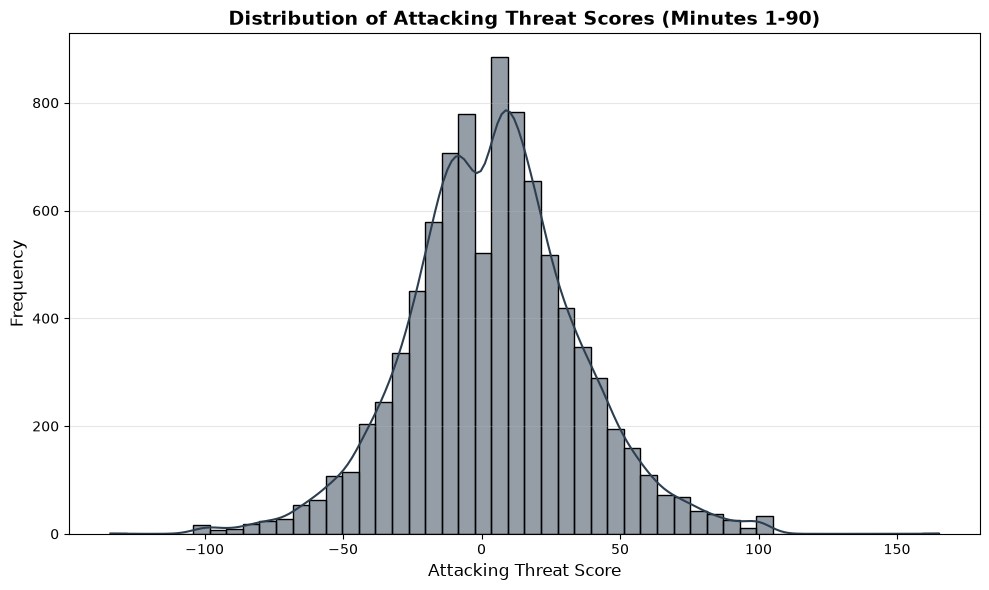

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('world_cup_momentum_dataset.csv')
df = df[df['minute'] == df['minute'].astype(int)]


# Filter for minutes 1 to 90 for the plot
df_plot = df[(df['minute'] >= 1) & (df['minute'] <= 90)].copy()

# Generate the plot
plt.figure(figsize=(10, 6))
sns.histplot(df_plot['value'], bins=50, kde=True, color='#2c3e50')

plt.title('Distribution of Attacking Threat Scores (Minutes 1-90)', fontsize=14, fontweight='bold')
plt.xlabel('Attacking Threat Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

My intuition led me to a rolling window approach. For any given minute, I look at the five minutes before and the five minutes after. I calculate the average momentum in both windows and look at the difference.
To formalize this, let $\Delta$ represent the shift in momentum for a given minute $t$. If we denote the average momentum of the 5 minutes preceding $t$ as $\bar{M}_{pre}$ and the average momentum of the 5 minutes following $t$ as $\bar{M}_{post}$, the momentum shift is defined as:$$\Delta_t = \bar{M}_{post} - \bar{M}_{pre}$$If $\vert{}\Delta_t\vert{} > 30$, I flag the minute as a potential 'break point'.

Why 30? There’s no magic formula here. After staring at the data and its distribution, 30 felt like the right threshold to filter out the "noise" of a normal match. But I'l try to make sure the treshold is vaild.

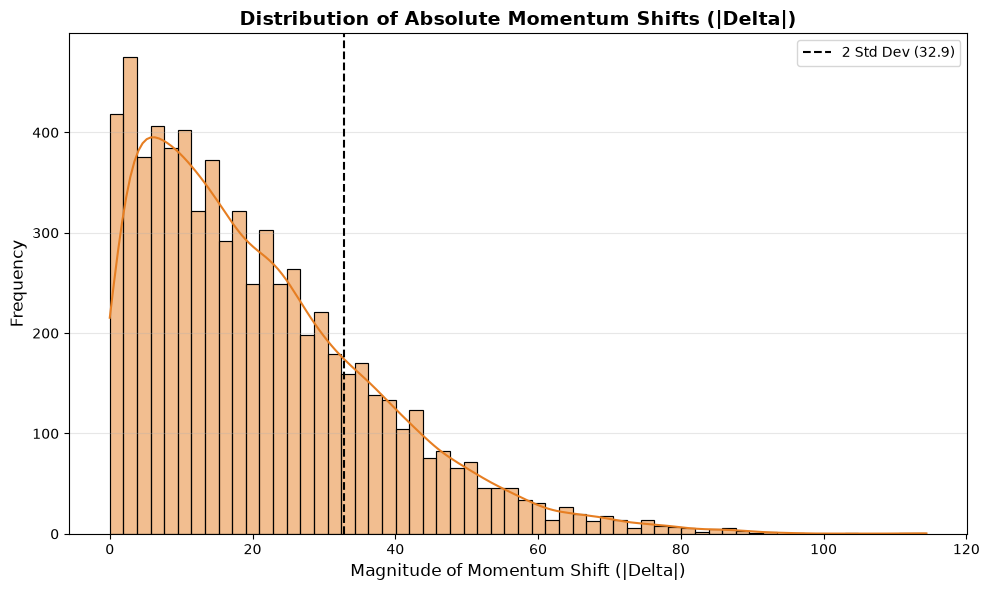

Standard Deviation of Absolute Delta: 16.43


In [2]:
# ==========================================
# 1. Calculate Rolling Metrics on Full Dataset
# ==========================================
def add_metrics(group):
    group['m_pre'] = group['value'].rolling(window=5).mean().shift(1)
    group['m_post'] = group['value'].rolling(window=5).mean().shift(-5)
    
    group['delta'] = (group['m_post'] - group['m_pre']).abs().round(2)
    group['trend'] = np.sign(group['m_post'] - group['m_pre'])
    return group

df_calc = df.groupby('match_id', group_keys=False).apply(add_metrics)

# ==========================================
# 2. Nullify Invalid Minutes (DO NOT DELETE ROWS)
# ==========================================
valid_mask = ((df_calc['minute'] >= 6) & (df_calc['minute'] <= 40)) | \
             ((df_calc['minute'] >= 51) & (df_calc['minute'] <= 85))

# Retain all rows while setting delta to zero for invalid minutes
df_all = df_calc.copy()
df_all.loc[~valid_mask, 'delta'] = 0 
# Reset moving average values to avoid artifacts in the plots
df_all.loc[~valid_mask, 'm_pre'] = np.nan
df_all.loc[~valid_mask, 'm_post'] = np.nan

# ==========================================
# 3. Plot Absolute Delta for Valid Minutes Only
# ==========================================
delta_clean = df_all.loc[valid_mask, 'delta'].dropna()
delta_std = delta_clean.std()

plt.figure(figsize=(10, 6))
sns.histplot(delta_clean, bins=60, kde=True, color='#e67e22')

plt.axvline(x=delta_std * 2, color='black', linestyle='--', label=f'2 Std Dev ({delta_std*2:.1f})')

plt.title('Distribution of Absolute Momentum Shifts (|Delta|)', fontsize=14, fontweight='bold')
plt.xlabel('Magnitude of Momentum Shift (|Delta|)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Standard Deviation of Absolute Delta: {delta_std:.2f}")

As we can see, two standard deviations amount to exactly 32.9. This gives me great confidence in choosing 30 as my threshold.

## Defining Momentum Break Points

Defining a momentum threshold is just the first step. The real challenge is that not every spike in data corresponds to a genuine momentum shift. My initial approach was simple: flag every minute where the absolute delta exceeded 30. However, this produced too much "noise" - it captured minor fluctuations and missed the true turning points that define the flow of a match.

To move from basic data filtering to actual **break point detection**, I treated the momentum graph as a continuous function $M(t)$ and analyzed its derivatives. I implemented three formal filters to ensure my break points were statistically and tactically significant:

### 1. The Zero-Cross Rule (Signal Direction)
A momentum shift is only a "break point" if it indicates a transition in control. Mathematically, I ensure that the sign of the momentum changes between the pre-event and post-event windows: 
$$\text{sgn}(\bar{M}_{pre}) \neq \text{sgn}(\bar{M}_{post})$$
This acts as a logical gate, ensuring we are isolating a flip in dominance, not just a temporary surge within the same team's period of control.

### 2. The Derivative-Based Shift Power
I wanted to capture not just the occurrence of a change, but its **aggression**. I calculated two distinct approximations of the first derivative:
* **Immediate derivative:** $D_1 = M_{t+1} - M_t$
* **Broader derivative:** $D_3 = M_{t+3} - M_t$

By combining these into a `shift_power` metric - defined as $S = D_1 + D_3$ - I created a sensitivity filter that prioritizes moments where the momentum is not only changing but accelerating rapidly. This serves as a second-order indicator of how strongly a team is seizing control.

### 3. The Sustainability Constraint (Temporal Consistency)
To filter out "noisy" outliers, I added a sustainability check. I require the sign of the momentum to remain consistent over a 3-minute window:
$$\sum_{i=0}^{3} \text{sgn}(M_{t+i}) \geq 3$$
This ensures that the shift represents a sustained change in the match state rather than a momentary flash.

***

By combining these filters - the zero-cross logic, the derivative-based acceleration metric ($S$), and the sustainability constraint - I created an engine that mimics how I, a random fan, "sees" the game. It effectively filters out the random chaos of football and isolates the moments where the tide truly turns.

In [3]:
# ==========================================
# 3. Break Point Detection: The Detection Engine
# ==========================================
def find_break_points_ultimate(df_match):
    df_match = df_match.copy()
    df_match['is_break_point'] = False
    
    # 1. First-Order Derivatives
    df_match['diff_1'] = df_match['value'].shift(-1) - df_match['value']
    df_match['diff_3'] = df_match['value'].shift(-3) - df_match['value']
    df_match['shift_power'] = df_match['diff_1'] + df_match['diff_3']
    
    # 2. Zero-Cross Rule
    is_momentum_flip = np.sign(df_match['m_pre']) != np.sign(df_match['m_post'])
    df_match['is_high_delta_zone'] = (df_match['delta'] >= 30) & is_momentum_flip
    
    # 3. Block Analysis
    df_match['block_id'] = (df_match['is_high_delta_zone'] != df_match['is_high_delta_zone'].shift(1)).cumsum()
    high_blocks = df_match[df_match['is_high_delta_zone']]
    
    for block_id, block in high_blocks.groupby('block_id'):
        start_idx = block.index[0]
        end_idx = block.index[-1]
        trend = block['trend'].mean()
        
        search_window = df_match.loc[max(0, start_idx - 5):end_idx]
        
        if len(search_window) > 3:
            if trend < 0:
                valid_candidates = search_window[search_window['diff_1'] < 0]
                if not valid_candidates.empty:
                    sorted_candidates = valid_candidates.sort_values('shift_power', ascending=True)
                    for break_point_idx in sorted_candidates.index:
                        # 4. Sustainability Check
                        next_mins = df_match.loc[break_point_idx : break_point_idx + 3, 'value']
                        if (next_mins < 0).sum() >= 3:
                            df_match.loc[break_point_idx, 'is_break_point'] = True
                            break 
                            
            else:
                valid_candidates = search_window[search_window['diff_1'] > 0]
                if not valid_candidates.empty:
                    sorted_candidates = valid_candidates.sort_values('shift_power', ascending=False)
                    for break_point_idx in sorted_candidates.index:
                        # 4. Sustainability Check
                        next_mins = df_match.loc[break_point_idx : break_point_idx + 3, 'value']
                        if (next_mins > 0).sum() >= 3:
                            df_match.loc[break_point_idx, 'is_break_point'] = True
                            break 
                            
    # Clean up helper columns
    df_match = df_match.drop(columns=['diff_1', 'diff_3', 'shift_power'])
    return df_match

# Execute on df_all containing all 90 minutes so shift and loc operations align correctly
df_final = df_all.groupby('match_id', group_keys=False).apply(find_break_points_ultimate)

print(f"Total break points identified: {df_final['is_break_point'].sum()}")

Total break points identified: 319


So, we ended up with 319 momentum shifts across 99 matches, which averages out to just over 3 shifts per game. Intuitively, that might sound a bit low. When most of us picture a football match, we think of those exciting, end-to-end moments where teams constantly trade attacks and the game shifts rapidly from one penalty box to the other.

But it's important to remember how we defined momentum here: we are looking for sustained periods of effective attacking. A true momentum break point requires a solid sequence of minutes on both sides of the shift where each team is genuinely threatening the goal. In reality, a typical football match includes a lot of feeling the opponent out, ineffective sideways passes, time-wasting, and long stretches where not much actually happens. 

This is especially true in international football, where the overall level of play is often lower than in club football. On top of that, with the expanded format of this World Cup, many games matched top-tier nations against much smaller ones, which naturally resulted in more one-sided matches.

Next, we want to check if the momentum break points we calculated actually align with the overall momentum flow of the matches. To do this, we’ll visualize the momentum data on a graph and mark the break points, drinks breaks, and goals. This will let us see everything in context and get a good visual feel for whether our model is actually working well.

In [4]:

# 1. Load team metadata
df_meta = pd.read_csv(r"all_minutes_momentum_analysis.csv")
meta_cols = ['match_id', 'home_team', 'away_team', 'favorite_team', 'underdog_team']
df_meta = df_meta[meta_cols].drop_duplicates()

# 2. Load event data (goals + drinks breaks)
df_events = pd.read_csv(r"world_cup_match_events.csv")

# Filter goals
df_goals = df_events[df_events['event_type'].str.lower() == 'goal'].copy()
df_goals['is_goal'] = True
df_goals = df_goals[['match_id', 'minute', 'is_goal']].drop_duplicates()

# Filter drinks breaks
df_drinks = df_events[df_events['event_type'].str.lower() == 'drinks_break'].copy()
df_drinks['is_exact_drinks_break'] = True
df_drinks = df_drinks[['match_id', 'minute', 'is_exact_drinks_break']].drop_duplicates()

# 3. Merge event and team metadata into df_final
df_final = df_final.merge(df_meta, on='match_id', how='left')
df_final = df_final.merge(df_goals, on=['match_id', 'minute'], how='left')
df_final = df_final.merge(df_drinks, on=['match_id', 'minute'], how='left')

# Fill missing event flags with False
df_final['is_goal'] = df_final['is_goal'].fillna(False)
df_final['is_exact_drinks_break'] = df_final['is_exact_drinks_break'].fillna(False)

In [5]:
def plot_match_momentum(match_id, df, ax=None):
    """
    Plots the momentum flow, break points, drinks breaks, and goals for a specific match.
    Supports plotting inside subplots using the optional 'ax' parameter.
    """
    df_match = df[df['match_id'] == match_id].copy()
    df_match = df_match.drop_duplicates(subset=['minute']).sort_values('minute')

    if df_match.empty:
        print(f"Match ID {match_id} not found in dataset.")
        return

    home_team = df_match['home_team'].iloc[0] if 'home_team' in df_match.columns else 'Home Team'
    away_team = df_match['away_team'].iloc[0] if 'away_team' in df_match.columns else 'Away Team'

    x = df_match['minute'].values
    y = df_match['value'].values

    # Smoothing via spline interpolation
    spl = make_interp_spline(x, y, k=3)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = spl(x_smooth)

    # Initialize standalone plot or use the provided axes
    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 7))
        is_standalone = True
    else:
        is_standalone = False

    # Define symmetric y-axis limits
    max_abs_val = max(abs(y_smooth.min()), abs(y_smooth.max()))
    padding = max_abs_val * 0.15 
    ax.set_ylim(-(max_abs_val + padding), (max_abs_val + padding))

    # Fill the area under the momentum curve
    ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth > 0), color='#d9534f', alpha=0.6, label=f'{home_team} Threat')
    ax.fill_between(x_smooth, y_smooth, 0, where=(y_smooth < 0), color='#5bc0de', alpha=0.6, label=f'{away_team} Threat')

    # Zero momentum baseline
    ax.axhline(0, color='black', linewidth=1)
    
    # Half-time indicator
    ax.axvline(x=45, color='black', linestyle='-.', linewidth=2, alpha=0.8, label='Half Time')

    # Drinks break windows
    if 'is_exact_drinks_break' in df_match.columns:
        exact_drinks = df_match[df_match['is_exact_drinks_break']]['minute']
        if not exact_drinks.empty:
            for db in exact_drinks:
                ax.axvline(x=db, color='#3498db', linestyle=':', linewidth=2.5, label='Drinks Break (Exact)' if db == exact_drinks.iloc[0] else "")
                ax.axvspan(db - 1, db + 2, color='#bdc3c7', alpha=0.4, label='Drinks Break Impact Window' if db == exact_drinks.iloc[0] else "")

    # Momentum break points
    if 'is_break_point' in df_match.columns:
        break_points = df_match[df_match['is_break_point']]['minute']
        if not break_points.empty:
            for bp in break_points:
                ax.axvline(x=bp, color='#f39c12', linestyle='--', linewidth=2.5, label='Momentum Break Point' if bp == break_points.iloc[0] else "")

    # Goal events
    if 'is_goal' in df_match.columns:
        goals = df_match[df_match['is_goal']]
        for i, row in goals.iterrows():
            gx = row['minute']
            gy = 0  # Fixed position on the zero line to avoid momentum bias
            
            # Using Segoe UI Emoji to prevent missing glyph warnings on Windows
            ax.text(gx, gy, '⚽', fontsize=12, ha='center', va='center', zorder=10, fontname='Segoe UI Emoji')
        
        if not goals.empty:
            ax.plot([], [], ' ', label='⚽ Goal')

    # Axis titles and styling
    ax.set_title(f'Match Momentum: {home_team} vs {away_team}', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Minute', fontsize=10, fontweight='bold')
    ax.set_ylabel('Attacking Threat', fontsize=10, fontweight='bold')
    
    ax.set_xlim(0, 90)
    ax.set_xticks(np.arange(0, 91, 5)) 
    ax.set_yticks([]) 
    
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    if is_standalone:
        plt.tight_layout()
        plt.show()

We will test the visualitaion on several exciting matches:

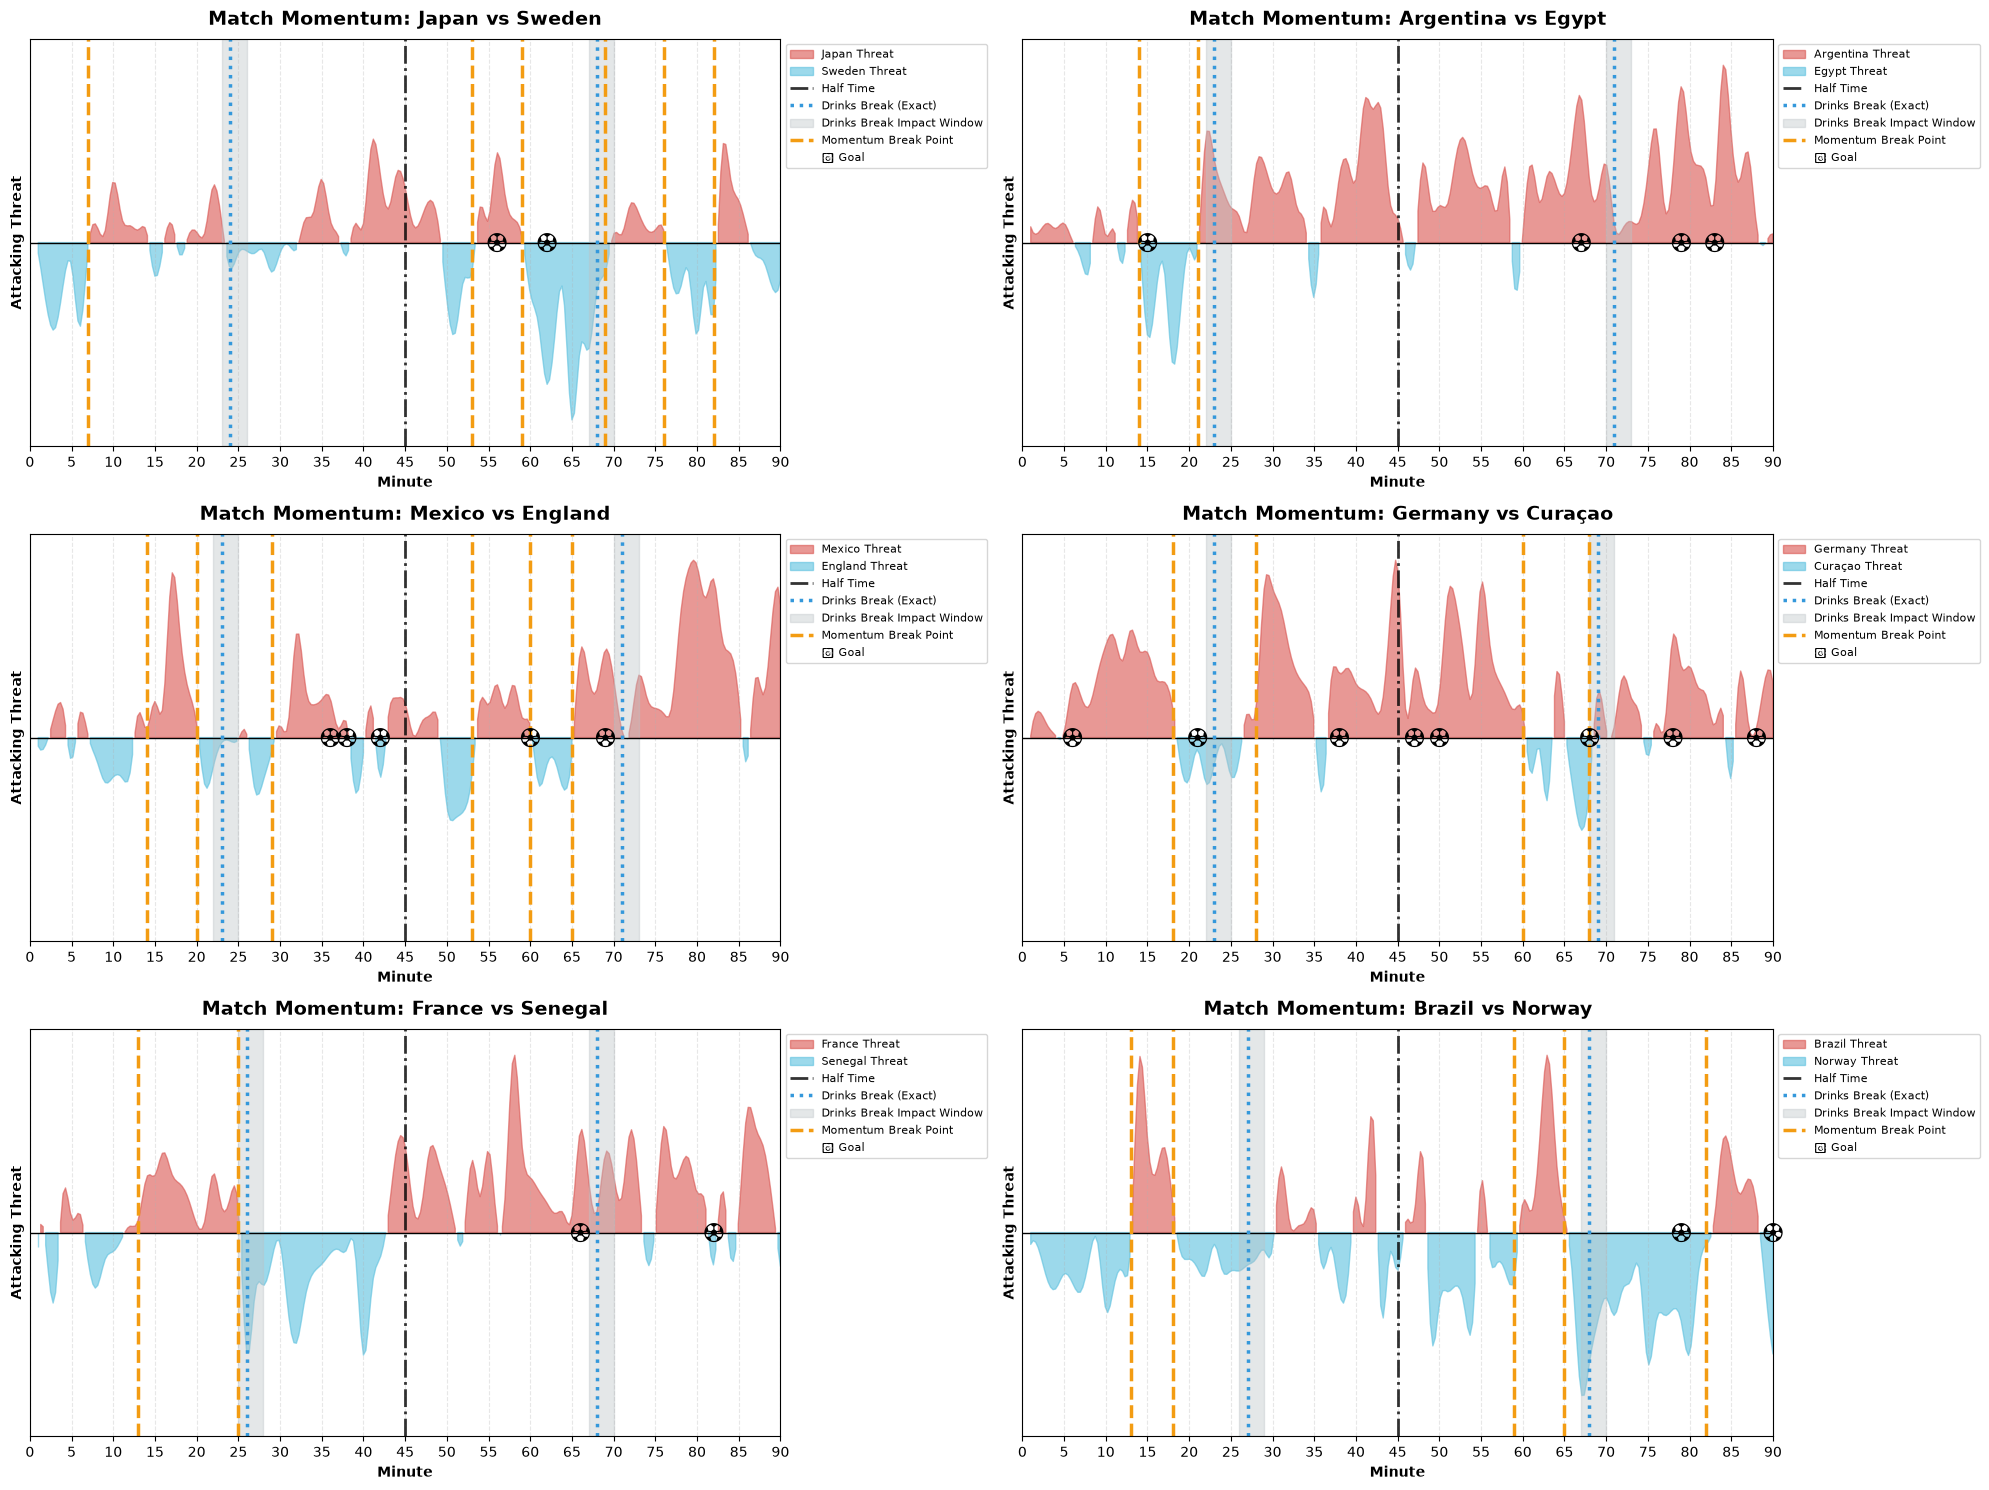

In [6]:
match_ids = [15186972, 12812993, 12813007, 15186899, 15186501, 12813006]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15))
axes = axes.flatten() 

for i, match_id in enumerate(match_ids):
    plot_match_momentum(match_id, df_final, ax=axes[i])

plt.tight_layout()
plt.show()

As we can clearly see in the visualized grids, the algorithm does an excellent job of identifying genuine momentum break points. It is designed to be rigorous: a simple, momentary change in possession is not enough to trigger a shift. Instead, the algorithm demands a substantial and sustained volume of attacking threat on both sides of the break point to classify it as a true, structural turning point in the match.

When examining these plots, there are two methodological nuances to keep in mind. First, the match data is capped at exactly 90 minutes, meaning we naturally lose a small fraction of information from extended stoppage time at the end of the game. Second, the visual representation of the attacking threat is smoothed using spline interpolation. Raw, minute-by-minute football data is inherently noisy, with the momentum constantly oscillating back and forth. Spline smoothing filters out this micro-level variance, preventing the graph from displaying jagged, aggressive spikes for every minor action on the pitch. This allows us to focus purely on the broader, underlying macro-trends of match dominance.

Up to this point, we’ve developed a formula we’re happy with for identifying momentum break points, finding an average of just over three break points per match. Now, we want to put our findings to a rigorous statistical test.

Specifically, we will use a **Monte Carlo Permutation Test**. The goal here is to answer a simple question: Do momentum shifts happen around drinks breaks because of the break itself, or could it just be a random coincidence? To test this, we take the actual number of break points that occurred in a match and randomly shuffle their timestamps across the valid minutes of that game. We repeat this process 10,000 times. By counting how many times these randomized break points accidentally fall near a drinks break, we generate a baseline of "random chance." If our actual observed data significantly deviates from this random baseline, we can confidently say the drinks breaks have a real impact.

To run this test, we first need to define the drinks break "impact window" - the timeframe where we consider a momentum shift to be a direct result of the stoppage. We defined this window as starting **one minute before** the break and ending **two minutes after** it.

* **Why one minute before?** Because our algorithm looks 5 minutes into the future to confirm a sustained momentum shift. If a break point is triggered one minute before the whistle, its validity is heavily dictated by what happens *during* and immediately *after* the break. Therefore, the drinks break directly influences this pre-whistle shift.
* **Why two minutes after?** The effect of a stoppage isn't instantaneous. When play resumes - usually from a dead ball or a throw-in - it takes a few moments for players to reorganize, for tactical adjustments to take shape, and for the match to find its rhythm again. The true impact of the break naturally unfolds over these first couple of minutes of resumed play.

I want to emphasize that defining the exact size of this window is my personal, intuitive choice rather than a mathematically proven one. Selecting a different timeframe could certainly yield slightly different results. Ultimately, this decision relies entirely on my own perception of the game and how I personally understand the natural flow of a football match on the pitch.


=== Monte Carlo Simulation Results ===
Average random break points in windows: 35.43
Observed break points: 22
P-value: 0.9967

CONCLUSION: NOT SIGNIFICANT 🔴
The observed momentum shifts around drinks breaks could easily occur by random chance.


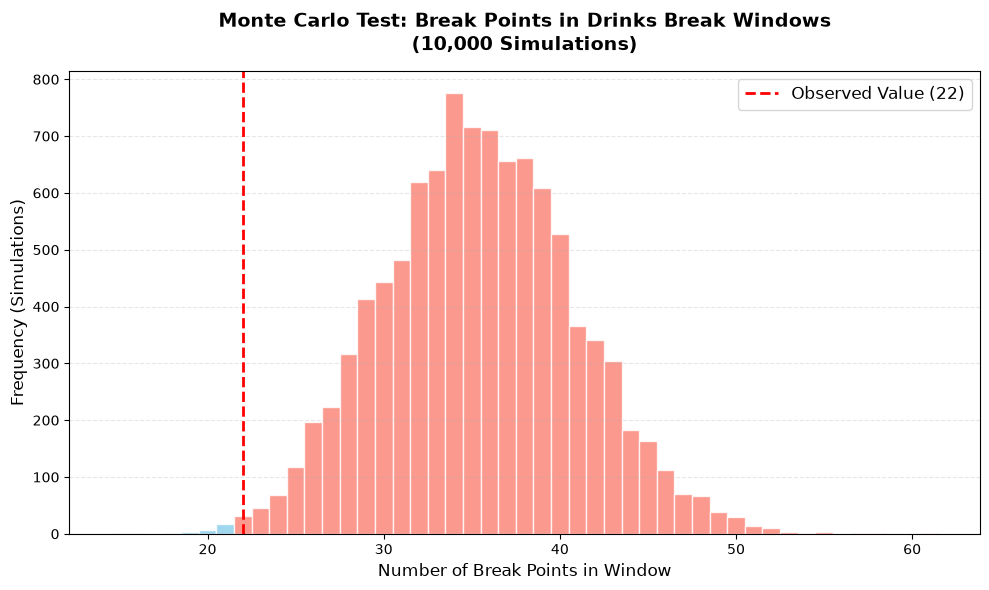

In [7]:
# ==========================================
# 1. Prepare Drinks Break Windows
# ==========================================
# Create a window representing the impact period (4 minutes) around each drinks break
df_final['is_drinks_break_window'] = False
exact_drinks = df_final[df_final['is_exact_drinks_break'] == True]

for _, row in exact_drinks.iterrows():
    m_id = row['match_id']
    db_min = row['minute']
    # Window: one minute before, the break minute, and two minutes after
    window = [db_min - 1, db_min, db_min + 1, db_min + 2]
    
    # Mark the window in the dataset
    df_final.loc[(df_final['match_id'] == m_id) & (df_final['minute'].isin(window)), 'is_drinks_break_window'] = True

# ==========================================
# 2. Filter Valid Minutes
# ==========================================
# Filter to valid minutes only (excluding the first and last 5 minutes of each half)
valid_mask = ((df_final['minute'] >= 6) & (df_final['minute'] <= 40)) | \
             ((df_final['minute'] >= 51) & (df_final['minute'] <= 85))
df_valid = df_final[valid_mask].copy()

# Count break points that occurred within drinks windows
observed_bps = df_valid[df_valid['is_drinks_break_window']]['is_break_point'].sum()

# ==========================================
# 3. Monte Carlo Permutation Test
# ==========================================
n_iterations = 10000
simulated_results = np.zeros(n_iterations)

# Permute break point labels within each match over valid minutes
for i in range(n_iterations):
    shuffled_bps = df_valid.groupby('match_id')['is_break_point'].transform(np.random.permutation)
    
    # Count how many permuted break points fall within drinks windows
    sim_count = shuffled_bps[df_valid['is_drinks_break_window']].sum()
    simulated_results[i] = sim_count

# Compute the exact p-value using permutation test correction
p_value = (np.sum(simulated_results >= observed_bps) + 1) / (n_iterations + 1)

# ==========================================
# 4. Print Results
# ==========================================
print("\n=== Monte Carlo Simulation Results ===")
print(f"Average random break points in windows: {simulated_results.mean():.2f}")
print(f"Observed break points: {observed_bps}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nCONCLUSION: SIGNIFICANT 🟢")
    print("The number of momentum shifts around drinks breaks is significantly higher than random chance.")
else:
    print("\nCONCLUSION: NOT SIGNIFICANT 🔴")
    print("The observed momentum shifts around drinks breaks could easily occur by random chance.")

# ==========================================
# 5. Plot the Distribution
# ==========================================
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(simulated_results, bins=range(int(simulated_results.min()), int(simulated_results.max()) + 2), 
                                 color='skyblue', edgecolor='white', align='left', alpha=0.8)

plt.axvline(x=observed_bps, color='red', linestyle='--', linewidth=2, label=f'Observed Value ({observed_bps})')

plt.title('Monte Carlo Test: Break Points in Drinks Break Windows\n(10,000 Simulations)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Break Points in Window', fontsize=12)
plt.ylabel('Frequency (Simulations)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Highlight the tail beyond the observed count
for patch, left_edge in zip(patches, bins[:-1]):
    if left_edge >= observed_bps:
        patch.set_facecolor('salmon')

plt.tight_layout()
plt.show()

Looking at the results of our 10,000 simulations, we observed only 22 momentum break points during drinks break windows - notably lower than the randomly expected average of 35.43. I didn't necessarily approach this expecting drinks breaks to be major influence for momentum shifts, and these results clearly confirm that, as a general rule, they are not.

In fact, the unusually low number of observed shifts highlights a different dynamic: rather than flipping momentum from one side to the other, a drinks break often acts as a general "reset" button. It calms the overall pace of the match. Both teams catch their breath, the general intensity drops, and the game tends to enter a more neutral, balanced phase. Because neither side immediately establishes sustained attacking pressure after the whistle, new momentum shifts are actually prevented from forming.

That being said, football is a highly complex game driven by countless variables, and a short stoppage is just one piece of the puzzle. While the overall statistical trend shows a cooling-off effect, a drinks break can absolutely be the direct cause of a momentum shift in specific scenarios - for example, if a manager uses the pause to deliver a crucial tactical change. It is simply that these instances are specific exceptions rather than the general rule.

So we've established that, in general, drinks breaks not only fail to trigger momentum shifts, but they actually decrease the likelihood of one occurring. But could the situation be different when we look specifically at momentum shifts favoring the stronger team? I decided to test this as well.

I defined a team as the clear "favorite" if their pre-match betting odds were 2.0 or lower. We will examine this using the exact same methodology as before.  we will run another Monte Carlo simulation, but this time we isolate only the specific break points where the momentum swung from the underdog to the favorite. By randomly shuffling these specific shifts across the valid minutes of the match 10,000 times, we can test whether drinks breaks act as a unique catalyst for favorites to take control, or if any overlap is still just random chance.


=== Monte Carlo Results: Underdog to Favorite Shifts ===
Average expected by random chance: 14.70
Actually observed: 10
P-value (Left-tail / Suppression): 0.1174
P-value (Right-tail / Catalyst): 0.9320


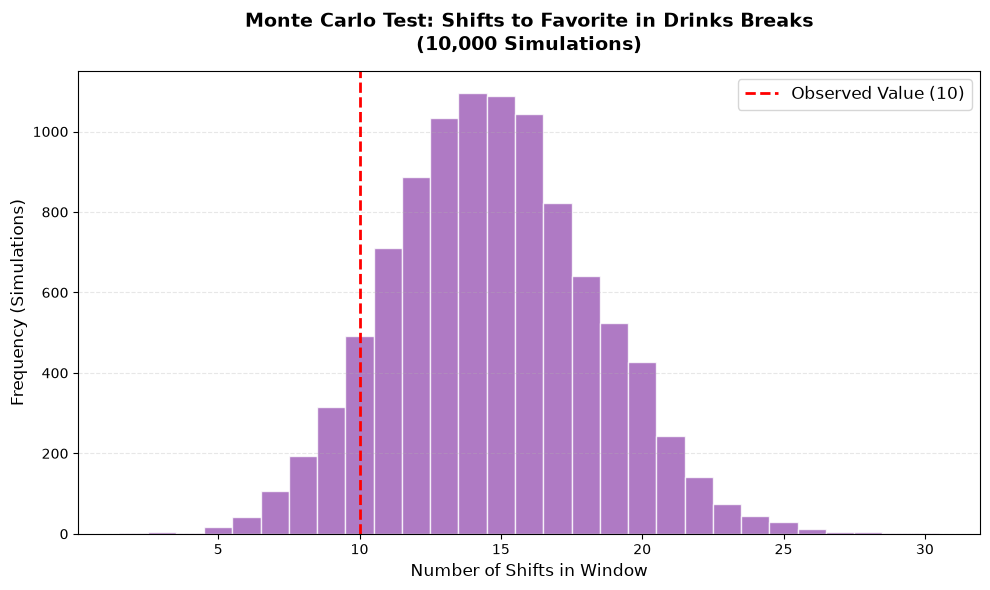

In [8]:
# ==========================================
# 1. Prepare Drinks Break Windows & Momentum Direction
# ==========================================
# Create a window representing the impact period (4 minutes) around each drinks break
df_final['is_drinks_break_window'] = False
exact_drinks = df_final[df_final['is_exact_drinks_break'] == True]

for _, row in exact_drinks.iterrows():
    m_id = row['match_id']
    db_min = row['minute']
    # Window: one minute before, the break minute, and two minutes after
    window = [db_min - 1, db_min, db_min + 1, db_min + 2]
    
    # Mark the window in the dataset
    df_final.loc[(df_final['match_id'] == m_id) & (df_final['minute'].isin(window)), 'is_drinks_break_window'] = True

# Calculate momentum direction BEFORE filtering minutes to keep natural sequence!
df_final['diff_1'] = df_final.groupby('match_id')['value'].shift(-1) - df_final['value']

# ==========================================
# 2. Filter Valid Minutes & Matches
# ==========================================
# Filter to valid minutes only (excluding the first and last 5 minutes of each half)
valid_mask = ((df_final['minute'] >= 6) & (df_final['minute'] <= 40)) | \
             ((df_final['minute'] >= 51) & (df_final['minute'] <= 85))
df_valid = df_final[valid_mask].copy()

# Drop matches where there is no clear favorite (e.g., 'Even')
df_valid = df_valid[df_valid['favorite_team'] != 'Even']

# ==========================================
# 3. Define: Momentum shift from Underdog to Favorite
# ==========================================
is_underdog_home = df_valid['underdog_team'] == df_valid['home_team']
is_underdog_away = df_valid['underdog_team'] == df_valid['away_team']

# Conditions for a shift to the favorite:
# 1. Underdog is Home (positive momentum) -> Shift downwards (negative derivative)
# 2. Underdog is Away (negative momentum) -> Shift upwards (positive derivative)
shift_to_fav = (is_underdog_home & (df_valid['diff_1'] < 0)) | (is_underdog_away & (df_valid['diff_1'] > 0))

# Intersect the condition with the actual existence of a break point
df_valid['is_break_to_favorite'] = df_valid['is_break_point'] & shift_to_fav

# Count break points that occurred within drinks windows
total_bps_to_fav = df_valid['is_break_to_favorite'].sum()
observed_bps = df_valid[df_valid['is_drinks_break_window']]['is_break_to_favorite'].sum()

# ==========================================
# 4. Monte Carlo Permutation Test
# ==========================================
n_iterations = 10000
simulated_results = np.zeros(n_iterations)

# Permute 'is_break_to_favorite' labels within each match
for i in range(n_iterations):
    shuffled_bps = df_valid.groupby('match_id')['is_break_to_favorite'].transform(np.random.permutation)
    
    # Count how many permuted break points fall within drinks windows
    sim_count = shuffled_bps[df_valid['is_drinks_break_window']].sum()
    simulated_results[i] = sim_count

# Compute p-values for both tails (+1 added to both numerator and denominator as standard practice)
p_value_left = (np.sum(simulated_results <= observed_bps) + 1) / (n_iterations + 1)
p_value_right = (np.sum(simulated_results >= observed_bps) + 1) / (n_iterations + 1)

# ==========================================
# 5. Print Results
# ==========================================
print("\n=== Monte Carlo Results: Underdog to Favorite Shifts ===")
print(f"Average expected by random chance: {simulated_results.mean():.2f}")
print(f"Actually observed: {observed_bps}")
print(f"P-value (Left-tail / Suppression): {p_value_left:.4f}")
print(f"P-value (Right-tail / Catalyst): {p_value_right:.4f}")

# ==========================================
# 6. Plot the Distribution
# ==========================================
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(simulated_results, bins=range(int(simulated_results.min()), int(simulated_results.max()) + 2), 
                                 color='#9b59b6', edgecolor='white', align='left', alpha=0.8)

plt.axvline(x=observed_bps, color='red', linestyle='--', linewidth=2, label=f'Observed Value ({observed_bps})')

plt.title('Monte Carlo Test: Shifts to Favorite in Drinks Breaks\n(10,000 Simulations)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Shifts in Window', fontsize=12)
plt.ylabel('Frequency (Simulations)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

The results here provide a fascinating nuance. We observed 10 instances where momentum shifted in favor of the pre-match favorite during a drinks break window. It is entirely possible - and even likely - that in these specific matches, the stoppage was the direct catalyst for the shift, perhaps allowing a manager to make a crucial tactical change that turned the game around. 

However, looking at the broader statistical picture, this number (10) is still lower than what we would expect to see by pure random chance (14.70). This highlights a crucial distinction: while a drinks break *can* certainly trigger a momentum swing for the stronger team, it does not do so systematically. The power dynamic between a favorite and an underdog doesn't turn the drinks break into a reliable tactical springboard. Even when factoring in team strength, the overall trend persists - drinks breaks generally tend to cool the game down rather than act as consistent catalysts for momentum shifts.

This brings us to what I believe is the bigger picture: football is a game of personal interpretation, and working with data is exactly the same. The choices I made throughout this project shaped the final results, and they reflect my own personal view of the game. 

This doesn't mean it is an absolute rule that drinks breaks always slow the game down and cause fewer momentum shifts; we can certainly find specific matches where the exact opposite happened. Ultimately, in a sport that is so much more than just a collection of stats, it is sometimes hard to see the whole picture just by looking at the numbers.